In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

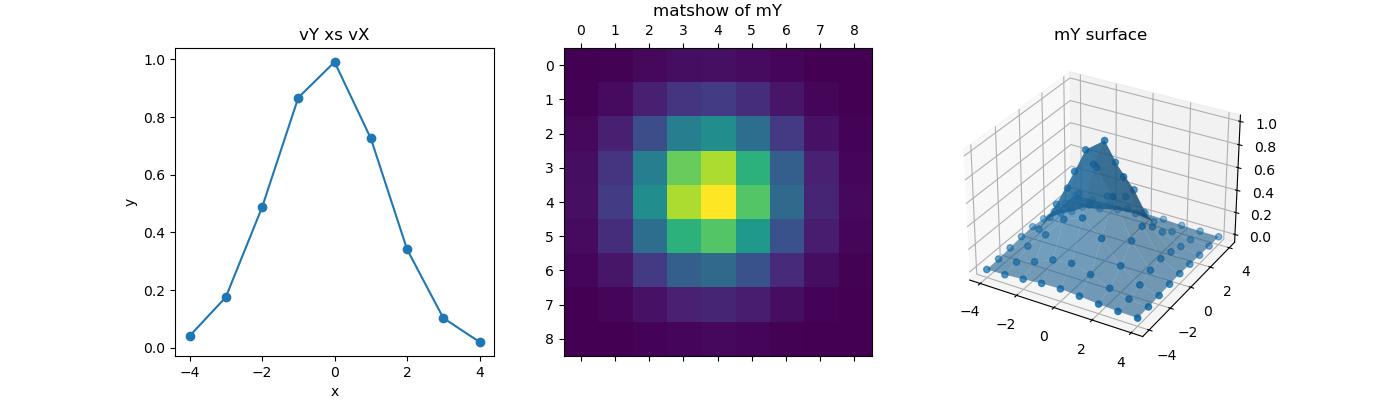

In [2]:
def gaussian(vX, mu, sigma):
    # gaussian function without normalization (just the bell shape)
    return np.exp(-0.5 * ((vX - mu)/ sigma)**2)

vX = np.linspace(-4, 4, 9)
vY = gaussian(vX, mu=-0.2, sigma=1.5) #values of vector vY can be seen on the left subplot
mY = np.outer(vY, vY) # creation of matrix by vY @ vY.T
mX1, mX2 = np.meshgrid(vX, vX) # creation of meshgrid for 3D subplot

fig = plt.figure(figsize=(14, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(vX, vY, marker='o')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('vY xs vX')

ax2 = fig.add_subplot(1, 3, 2)
ax2.matshow(mY)
ax2.set_title('matshow of mY')

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.scatter(mX1.flatten(), mX2.flatten(), mY.flatten())
ax3.plot_surface(mX1, mX2, mY, alpha=0.6)
ax3.set_title('mY surface')

plt.show()

In [3]:
mX2.flatten()


array([-4., -4., -4., -4., -4., -4., -4., -4., -4., -3., -3., -3., -3.,
       -3., -3., -3., -3., -3., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -1., -1., -1., -1., -1., -1., -1., -1., -1.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  4.,  4.,  4.,  4.,  4.,  4.,
        4.,  4.,  4.])

In [4]:
def build_mat_H(mX1, mX2):
    num_points = mX1.size
    H = np.array([
        np.ones(num_points),
        mX2.flatten(),
        mX1.flatten(),
        mX1.flatten() * mX1.flatten(),
        mX2.flatten() ** 2,
        mX1.flatten() ** 2 
    ])
    H = H.T
    return H

In [5]:
mH = build_mat_H(mX1, mX2)
w, *_ = np.linalg.lstsq(mH, mY.flatten(), rcond=None)

In [6]:
mA = np.array([[w[5], w[3]],
               [w[3], w[4]]])
vB =np.array([w[2], w[1]])
valC = w[0]

In [7]:
mXY = np.array([mX1.flatten(),
                mX2.flatten()])
vYest = np.array([mXY[:, i].T @ mA @ mXY[:, i] + np.dot(vB, mXY[:, i]) + valC  for i in range(mXY.shape[1])])


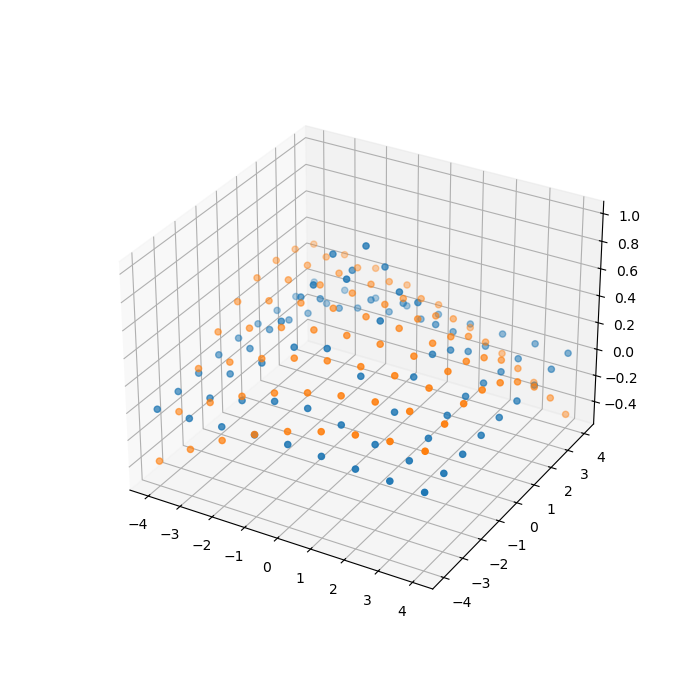

In [8]:
fig = plt.figure(figsize=(7, 7))
ax1 = fig.add_subplot(111, projection='3d')
ax1.scatter(mX1.flatten(), mX2.flatten(), mY.flatten())
ax1.scatter(mXY[0, :], mXY[1, :], vYest)
plt.show()